# Colab Template - Tarea VAE y GAN

**Nombre:** VARGAS REGALADO KEYLA SOFIA
**Curso:** Modelos de Deep Learning

> Sigue este notebook como guía de implementación para la tarea Beginner.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

BATCH_SIZE = 128
train_ds = tf.data.Dataset.from_tensor_slices(x_train).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(x_train.shape, x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1) (10000, 28, 28, 1)


## Problema 1 - VAE básico

Completa este bloque para entrenar y evaluar tu VAE.


In [3]:
latent_dim = 8

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

# Encoder
enc_in = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(enc_in)
x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
z_mean = layers.Dense(latent_dim, name='z_mean')(x)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(enc_in, [z_mean, z_log_var, z], name='encoder')

# Decoder
dec_in = keras.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation='relu')(dec_in)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
dec_out = layers.Conv2D(1, 3, padding='same', activation='sigmoid')(x)
decoder = keras.Model(dec_in, dec_out, name='decoder')

class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.loss_tracker = keras.metrics.Mean(name='loss')
        self.recon_tracker = keras.metrics.Mean(name='recon_loss')
        self.kl_tracker = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.loss_tracker, self.recon_tracker, self.kl_tracker]

    def train_step(self, data):
        x = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x)
            x_hat = self.decoder(z)
            recon = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(x, x_hat), axis=(1, 2)))
            kl = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
            loss = recon + self.beta * kl
        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.loss_tracker.update_state(loss)
        self.recon_tracker.update_state(recon)
        self.kl_tracker.update_state(kl)
        return {'loss': self.loss_tracker.result(), 'recon_loss': self.recon_tracker.result(), 'kl_loss': self.kl_tracker.result()}

vae = VAE(encoder, decoder, beta=1.0)
vae.compile(optimizer=keras.optimizers.Adam(1e-3))
history_vae = vae.fit(train_ds, epochs=10)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - kl_loss: 7.7080 - loss: 191.3496 - recon_loss: 183.6415
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 14.3177 - loss: 126.0853 - recon_loss: 111.7676
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 15.3655 - loss: 118.0069 - recon_loss: 102.6414
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 15.9888 - loss: 114.2951 - recon_loss: 98.3062
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 16.2403 - loss: 112.3260 - recon_loss: 96.0857
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 16.4067 - loss: 111.0464 - recon_loss: 94.6396
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 16.5268 - loss: 110.1310 - recon_loss: 93.6042
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 16.6307 - loss: 109.3118 - recon_loss: 92.6811
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 16.7361 - loss: 108.7260 - recon_loss: 91.9899
Epoch 

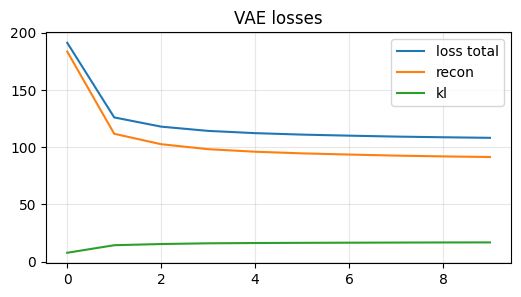

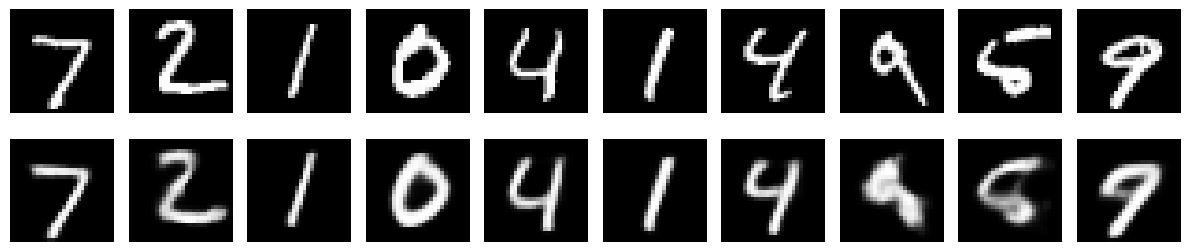

In [4]:
plt.figure(figsize=(6,3))
plt.plot(history_vae.history['loss'], label='loss total')
plt.plot(history_vae.history['recon_loss'], label='recon')
plt.plot(history_vae.history['kl_loss'], label='kl')
plt.legend(); plt.grid(alpha=0.3); plt.title('VAE losses'); plt.show()

# Reconstrucciones
x_sample = x_test[:10]
x_rec = vae.decoder(vae.encoder(x_sample)[2]).numpy()

fig, ax = plt.subplots(2,10, figsize=(12,3))
for i in range(10):
    ax[0,i].imshow(x_sample[i].squeeze(), cmap='gray'); ax[0,i].axis('off')
    ax[1,i].imshow(x_rec[i].squeeze(), cmap='gray'); ax[1,i].axis('off')
ax[0,0].set_ylabel('Original')
ax[1,0].set_ylabel('Recon')
plt.tight_layout(); plt.show()


## Problema 2 - GAN básica

Entrena la GAN y luego compara visualmente con VAE.


In [5]:
latent_dim = 100

# Discriminador
inp = keras.Input(shape=(28,28,1))
x = layers.Conv2D(64, 3, strides=2, padding='same')(inp)
x = layers.LeakyReLU(0.2)(x)
x = layers.Dropout(0.3)(x)
x = layers.Conv2D(128, 3, strides=2, padding='same')(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Dropout(0.3)(x)
x = layers.Flatten()(x)
out = layers.Dense(1, activation='sigmoid')(x)
discriminator = keras.Model(inp, out)
discriminator.compile(optimizer=keras.optimizers.Adam(2e-4, beta_1=0.5), loss='binary_crossentropy')

# Generador
z_in = keras.Input(shape=(latent_dim,))
x = layers.Dense(7*7*128)(z_in)
x = layers.Reshape((7,7,128))(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Conv2DTranspose(128, 4, strides=2, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.Conv2DTranspose(64, 4, strides=2, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(0.2)(x)
g_out = layers.Conv2D(1, 3, padding='same', activation='sigmoid')(x)
generator = keras.Model(z_in, g_out)

# GAN combinada
discriminator.trainable = False
z = keras.Input(shape=(latent_dim,))
valid = discriminator(generator(z))
combined = keras.Model(z, valid)
combined.compile(optimizer=keras.optimizers.Adam(2e-4, beta_1=0.5), loss='binary_crossentropy')

EPOCHS = 15
steps_per_epoch = 150
d_hist, g_hist = [], []

for epoch in range(EPOCHS):
    d_losses, g_losses = [], []
    for _ in range(steps_per_epoch):
        idx = np.random.randint(0, x_train.shape[0], BATCH_SIZE)
        real = x_train[idx]
        noise = np.random.normal(0,1,(BATCH_SIZE,latent_dim)).astype('float32')
        fake = generator.predict(noise, verbose=0)

        real_y = np.ones((BATCH_SIZE,1), dtype='float32') * 0.9
        fake_y = np.zeros((BATCH_SIZE,1), dtype='float32')

        discriminator.trainable = True
        d_real = discriminator.train_on_batch(real, real_y)
        d_fake = discriminator.train_on_batch(fake, fake_y)
        d_loss = 0.5 * (float(d_real) + float(d_fake))

        discriminator.trainable = False
        noise = np.random.normal(0,1,(BATCH_SIZE,latent_dim)).astype('float32')
        valid_y = np.ones((BATCH_SIZE,1), dtype='float32')
        g_loss = float(combined.train_on_batch(noise, valid_y))

        d_losses.append(d_loss)
        g_losses.append(g_loss)

    d_hist.append(np.mean(d_losses))
    g_hist.append(np.mean(g_losses))
    print(f'Epoch {epoch+1}/{EPOCHS} - D: {d_hist[-1]:.4f} - G: {g_hist[-1]:.4f}')


Epoch 1/15 - D: 0.3676 - G: 0.5565
Epoch 2/15 - D: 0.3582 - G: 0.3208
Epoch 3/15 - D: 0.5095 - G: 0.4151
Epoch 4/15 - D: 0.5890 - G: 0.5250
Epoch 5/15 - D: 0.6262 - G: 0.5938
Epoch 6/15 - D: 0.6467 - G: 0.6360
Epoch 7/15 - D: 0.6595 - G: 0.6645
Epoch 8/15 - D: 0.6680 - G: 0.6845
Epoch 9/15 - D: 0.6737 - G: 0.6999
Epoch 10/15 - D: 0.6777 - G: 0.7125
Epoch 11/15 - D: 0.6805 - G: 0.7229
Epoch 12/15 - D: 0.6823 - G: 0.7316
Epoch 13/15 - D: 0.6836 - G: 0.7391
Epoch 14/15 - D: 0.6844 - G: 0.7456
Epoch 15/15 - D: 0.6849 - G: 0.7513


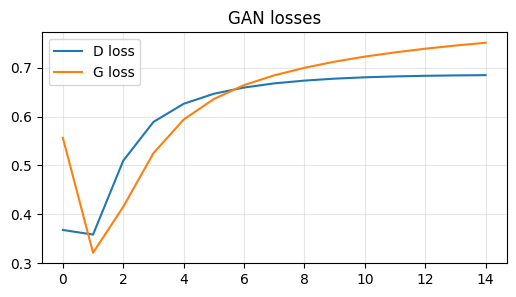

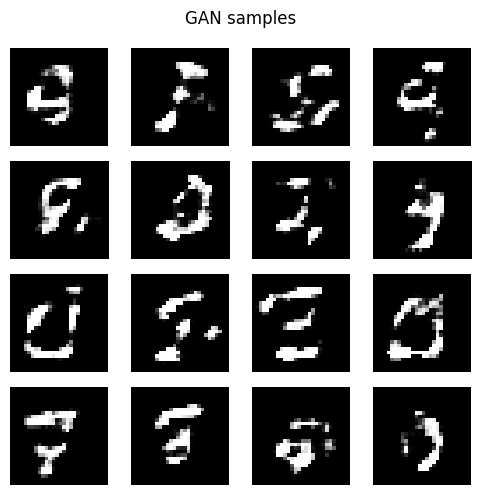

In [6]:
plt.figure(figsize=(6,3))
plt.plot(d_hist, label='D loss')
plt.plot(g_hist, label='G loss')
plt.title('GAN losses')
plt.legend(); plt.grid(alpha=0.3); plt.show()

# Muestras GAN
noise = np.random.normal(0,1,(16,latent_dim)).astype('float32')
samples = generator.predict(noise, verbose=0)

fig, ax = plt.subplots(4,4, figsize=(5,5))
for i, a in enumerate(ax.ravel()):
    a.imshow(samples[i].squeeze(), cmap='gray')
    a.axis('off')
plt.suptitle('GAN samples')
plt.tight_layout(); plt.show()


## Conclusiones (completar)

- ¿Qué modelo reconstruye mejor?
El VAE reconstruye mejor. En la imagen 1 se ve claramente que las reconstrucciones (fila inferior) son muy fieles a los originales (fila superior): los dígitos 7, 2, 1, 0, 4, 1, 4, 9, 5, 9 se reconocen con nitidez. El GAN no está diseñado para reconstruir, sino para generar desde ruido aleatorio.
- ¿Qué modelo genera imágenes más nítidas?
El VAE genera imágenes más nítidas en este caso, aunque paradójicamente tiende a producir imágenes algo borrosas por naturaleza. Sin embargo, las muestras del GAN (imagen 3) se ven fragmentadas, con artefactos y poco coherentes, lo que indica que con solo 15 épocas el GAN no convergió suficientemente.
- ¿Qué tan estable fue el entrenamiento?
VAE: El entrenamiento fue muy estable. Las tres pérdidas (total, recon y KL) descendieron de forma suave y progresiva a lo largo de las épocas, mostrando una convergencia clara y sin oscilaciones bruscas.

RESUMEN

El VAE fue más fácil de entrenar, más estable y produjo mejores resultados visuales en este experimento. El GAN necesitaría más épocas, ajuste de hiperparámetros (learning rate, arquitectura) o técnicas como label smoothing para mejorar la calidad de sus muestras.
